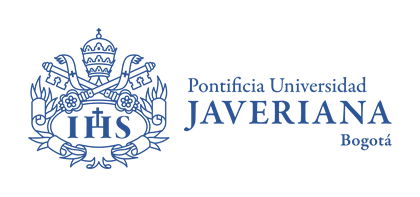

# Aprendizaje de máquina - Taller 2 - Redes neuronales artificiales
En este notebook vamos a explorar implementaciones de redes neuronales feedforward en usando la librería keras y se propone el enunciado del taller 2 del curso.

## Setup

Importaremos las librerías necesarias para el ejercicio

In [1]:
import pandas as pd
import numpy as np
from sklearn import pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split


I0000 00:00:1789435429.407298  550069 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789435429.453931  550069 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789435430.420962  550069 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Redes neuronales artificiales feedforward

Las redes neuronales de alimentación hacia adelante son modelos de aprendizaje de máquina que conectan las unidades neuronales en capas. Estos modelos tienen una capa de entrada que recibe las instancias, una o más capas intermedias o capas ocultas, y una capa de salida o final que da la respuesta según el problema a resolver (regresión o clasificación). Las unidades neuronales de una capa reciben las activaciones de todas las unidades neuronales de la capa anterior y conectan su activación a todas las unidades neuronales de la capa siguiente.


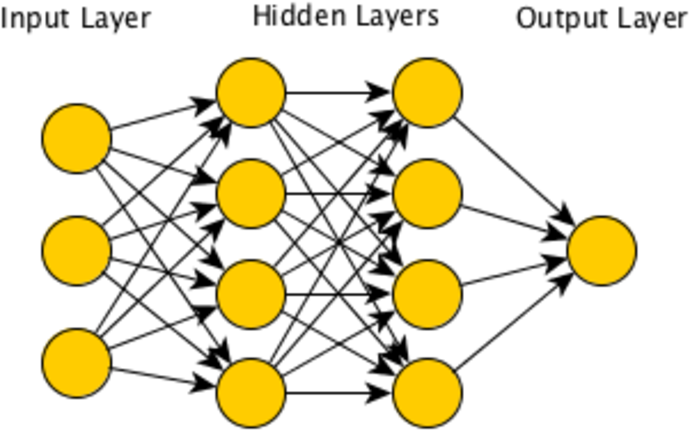

Las redes neuronales artificiales de alimentación hacia adelante son modeladores universales de funciones siempre y cuando se puedan añadir [suficientes unidades neuronales o suficientes capas](https://en.wikipedia.org/wiki/Universal_approximation_theorem)






## Ejercicio - Espirales

Ilustremos inicialmente el uso del modelo de clasificación de redes neuronales utilizando el ejemplo de las espirales que no eran separables por el perceptrón o ADALINE.




In [2]:
N=1000

In [3]:
def twospirals(n_points, noise=.5):
    """
     Returns the two spirals dataset.
    """
    n = np.sqrt(np.random.rand(n_points,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_points,1) * noise
    d1y = np.sin(n)*n + np.random.rand(n_points,1) * noise
    return (np.vstack((np.hstack((d1x,d1y)),np.hstack((-d1x,-d1y)))),
            np.hstack((np.zeros(n_points),np.ones(n_points))))

X, y = twospirals(N)

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [5]:
X_train.shape

(1600, 2)

In [6]:
X_test.shape

(400, 2)

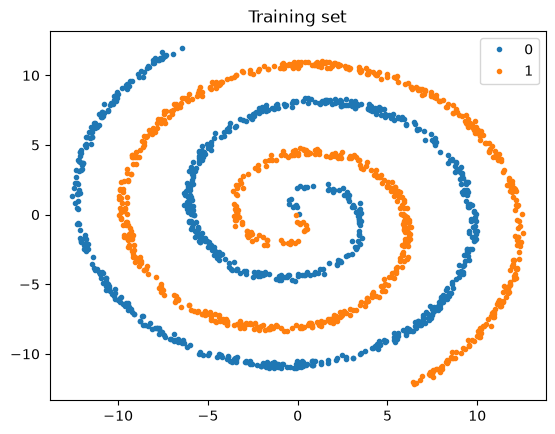

In [7]:
plt.title('Training set')
plt.plot(X_train[Y_train==0,0], X_train[Y_train==0,1], '.', label=0)
plt.plot(X_train[Y_train==1,0], X_train[Y_train==1,1], '.', label=1)
plt.legend()
plt.show()

### Partición datos en entrenamiento, validación y test

A continuación crearemos 3 datasets a partir del dataset no separable linealmente

In [8]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [9]:
X_val,X_test, y_val,y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)

In [10]:
len(X_train)

1600

In [11]:
len(X_val)

200

In [12]:
len(X_test)

200

## Construcción del modelo utilizando Tensorflow/Keras

Keras es una librería integrada con TensorFlow para el desarrollo rápido de modelos de aprendizaje de máquina. Keras implementa abstracciones comunes para problemas de aprendizaje profundo como capas, optimizadores, funciones de pérdida y regularización, entre otros.

La clase Sequential ([documentación](https://keras.io/api/models/sequential/)) permite inicializar un modelo feedforward vacío al que vamos a ir añadiendo capas densas.

Secuential recibe el tamaño de elementos que se esperan (forma del vector que se alimenta como instancia)

In [13]:
model = keras.Sequential([keras.Input(shape=(len(X_train[1]),))])

En el paquete [layers](https://keras.io/api/layers/) de keras, ya están implementadas diferentes tipos de capas a añadir a una red neuronal. En nuestro caso vamos a usar una capa densa para construir una red feed-forward. Para esto vamos a usar una capa [Dense](https://keras.io/api/layers/core_layers/dense/)

La capa Dense debe recibir el número de unidades neuronales de la capa, en este caso vamos a usar 8 neuronas en una única capa.

Otros parámetros importantes que debemos indicar al inicializar una capa son:


*   activation: El tipo de función de activación de las unidades neuronales de la capa




In [14]:
model.add(layers.Dense(8, activation='relu'))

I0000 00:00:1789435431.476909  550069 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


La última capa que se añade al modelo es la capa de salida, en este caso como es un problema de clasificación binaria, debemos usar la activación sigmoide para una única neurona de salida.

In [15]:
model.add(layers.Dense(1, activation='sigmoid'))

Una vez finalizada la construcción del modelo, se pasa a compilarlo. En la compilación establecemos principalmente 2 elementos:

*   El algoritmo de optimización que se va a aplicar. Puede encontrar más información acerca de los opimizadores disponibles en keras siguiendo el siguiente [link](https://keras.io/api/optimizers/#available-optimizers)

*   La función que se va a optimizar y frente a la cuál el framework va a realizar automáticamente las actualizaciones de los pesos, calculando el gradiente. Puede encontrar más información acerca de las funciones de pérdida a optimizar siguiendo el siguiente [link](https://keras.io/api/losses/)

* Funciones que se quieran monitorear en el proceso de aprendizaje. A estas se les conoce como metrics. Puede encontrar más información sobre las métricas de monitoreo en el siguiente [link](https://keras.io/api/metrics/).

En este ejemplo, vamos a optimizar utilizando el algoritmo Adam, y la función de pérdida es la función de errores mínimos cuadrados. Como métrica para monitorear el modelo vamos a usar la raiz del error mínimo cuadrado.



In [16]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=[keras.metrics.Accuracy()])

Una vez optimizado el modelo, podemos observar la arquitectura de red compilada utilizando la función summary del modelo.

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Al llamar el método fit del modelo, se comenzará el proceso de feed-forward y backpropagation utilizando el conjunto de datos de entrenamiento, para esto debemos pasar al algoritmo la entrada `train_df[features]` y el resultado esperado `train_df[col_y]`. Además debemos indicar el número de épocas para el que vamos a presentar los datos a la red y el tamaño del mini-batch que se va a usar para calcular el gradiente.

Al ejecutar la siguiente instrucción , keras iniciará el proceso de entrenamiento. Al final de cada época, el framework reportará el valor de la función de pérdida promedio.

In [18]:
history = model.fit(x=X_train,y=y_train, epochs=300, batch_size=4)

Epoch 1/300


I0000 00:00:1789435432.667294  553293 service.cc:153] XLA service 0x7f8b28030e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789435432.667309  553293 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1789435432.678477  553293 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789435432.794695  553293 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1789435432.798845  553293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_915__.7


 62/400 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.4216

I0000 00:00:1789435433.101764  553293 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0000e+00 - loss: 1.0395
Epoch 2/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6857
Epoch 3/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6688
Epoch 4/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6653
Epoch 5/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6632
Epoch 6/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6627
Epoch 7/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6620
Epoch 8/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6620
Epoch 9/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6618
Epoch 10/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6612
Epoch 11/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.6583
Epoch 12/

Grafiquemos la historia de entrenamiento de la red comparando la época con el loss

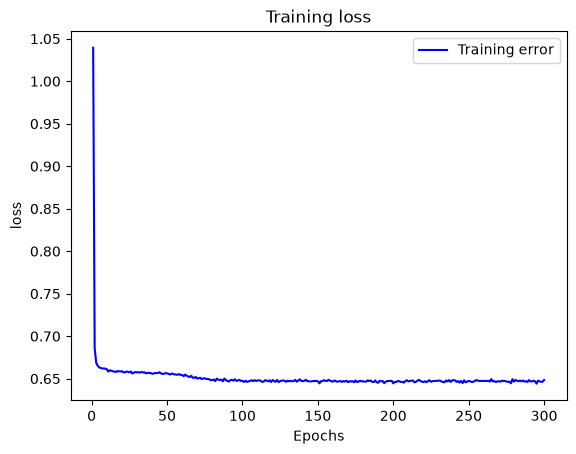

In [19]:
loss = history.history['loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training error')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

Revisemos en el conjunto de test la medida del error.

In [20]:
predictions= model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [21]:
predictions.shape

(200, 1)

In [22]:
y_test.shape

(200,)

In [23]:
df_y=pd.DataFrame(np.concatenate((predictions, y_test.reshape(-1,1)),axis=1), columns=['predictions','true'])

In [24]:
df_y

,predictions,true
0,0.531438,0.0
1,0.779255,1.0
2,0.508330,0.0
3,0.338430,1.0
4,0.379657,0.0
...,...,...
195,0.486605,1.0
196,0.265186,0.0
197,0.533771,0.0
198,0.337246,0.0


In [25]:
df_y['predict_bin']=(df_y['predictions']>0.5).astype(int)

In [26]:
df_y

,predictions,true,predict_bin
0,0.531438,0.0,1
1,0.779255,1.0,1
2,0.508330,0.0,1
3,0.338430,1.0,0
4,0.379657,0.0,0
...,...,...,...
195,0.486605,1.0,0
196,0.265186,0.0,0
197,0.533771,0.0,1
198,0.337246,0.0,0


In [27]:
df_y['true'].value_counts()

true
1.0    108
0.0     92
Name: count, dtype: int64

In [28]:
confusion_matrix(df_y['true'].astype(int),df_y['predict_bin'])

array([[58, 34],
       [55, 53]])

In [29]:

precision = precision_score(df_y['true'].astype(int), df_y['predict_bin'])
recall = recall_score(df_y['true'].astype(int), df_y['predict_bin'])
f1 = f1_score(df_y['true'].astype(int), df_y['predict_bin'])

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.6092
Recall: 0.4907
F1-Score: 0.5436


Se realiza la predicción sobre una grilla de puntos para visualizar decisión actual

51346/51346 ━━━━━━━━━━━━━━━━━━━━ 59s 1ms/step
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


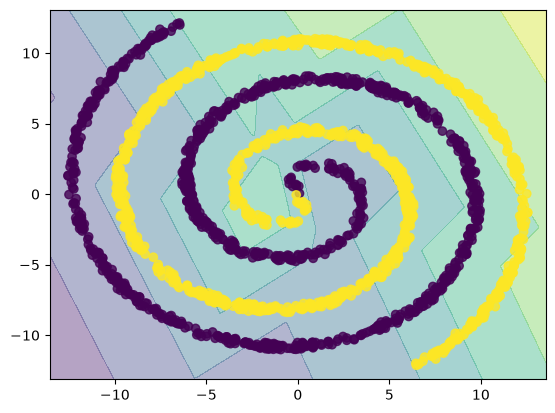

In [30]:
# Código tomado de https://github.com/tirthajyoti/Machine-Learning-with-Python/blob/master/Utilities/ML-Python-utils.py

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = .02     # point in the mesh [x_min, m_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
# Meshgrid creation
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh using the model.
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                      np.arange(y_min, y_max, 0.1))

# Predictions to obtain the classification results
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plotting
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)

### Callbacks

Desafortunadamente, la anterior gráfica de entrenamiento no nos dice mucho acerca del performance del modelo en los datos de test y nos plantea las siguientes preguntas: ¿Cuántas épocas debemos utilizar?, ¿Será que con menos épocas se logra un mejor resultado, o faltan épocas?. Al utilizar métodos de momento y mini-batches para entrenar se puede obsevar que el error de entrenamiento aunque disminuye en el tiempo puede aumentar en una iteración. Y si estoy "de malas" y justo en el número de épocas suministrada el error sube, ¿estoy obteniendo el mejor modelo?

El conjunto de validación (val_df) se utiliza con el fin de poder seguir más de cerca el proceso de aprendizaje época a época y dar solución a este tipo de inquietudes. La idea es revisar al final de la época el performance del modelo con datos que la red no esta utilizando para disminuir la pérdida, con el fin de diagnosticar de mejor manera si estamos en un escenario de alta varianza o alto sesgo.  Este conjunto se puede configurar de 2 formas diferentes, utilizando los siguientes parámetros:



*   validation_split: Porcentaje de datos del conjunto de entrenamiento que se separa del conjunto de entrenamiento para validar métricas de error.
*   validation_data: Directamente el conjunto de datos si se separó con anterioridad.



In [31]:
# Construyamos de nuevo el modelo para revisar cómo progresa el entrenamiento en validación

model = keras.Sequential([keras.Input(shape=(len(X_train[1]),))])
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
# También vamos a cambiar la tasa de aprendizaje del optimizador, para eso utilizo Adam con un lr diferentes
model.compile(optimizer=Adam(learning_rate=0.01),loss='binary_crossentropy',metrics=[keras.metrics.Accuracy()])
history = model.fit(x=X_train,y=y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val))



Epoch 1/300


I0000 00:00:1789435797.788419  553288 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_860840__.7


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0000e+00 - loss: 0.8570 - val_accuracy: 0.0000e+00 - val_loss: 0.6803
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6647 - val_accuracy: 0.0000e+00 - val_loss: 0.6751
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.6624 - val_accuracy: 0.0000e+00 - val_loss: 0.6640
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.6626 - val_accuracy: 0.0000e+00 - val_loss: 0.6728
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6623 - val_accuracy: 0.0000e+00 - val_loss: 0.6634
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6624 - val_accuracy: 0.0000e+00 - val_loss: 0.6825
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6613 - val_accuracy: 0.0000e+00 - val_loss: 0.6794
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0

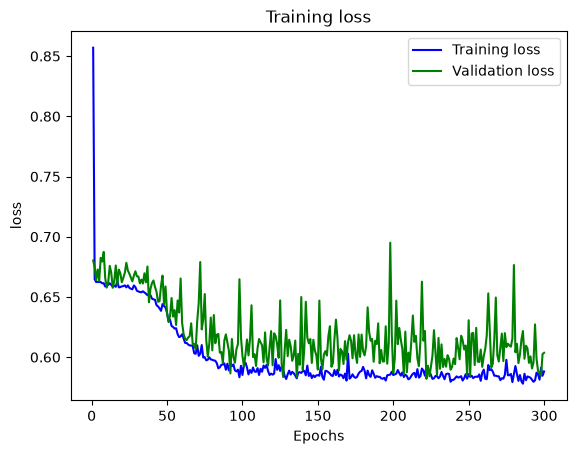

In [32]:
loss = history.history['loss']
val_loss= history.history['val_loss']
epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'g', label='Validation loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [33]:
predictions= model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [34]:
predictions.shape

(200, 1)

In [35]:
y_test.shape

(200,)

In [36]:
df_y=pd.DataFrame(np.concatenate((predictions, y_test.reshape(-1,1)),axis=1), columns=['predictions','true'])

In [37]:
df_y

,predictions,true
0,0.352188,0.0
1,0.748257,1.0
2,0.338732,0.0
3,0.299864,1.0
4,0.341070,0.0
...,...,...
195,0.460192,1.0
196,0.000002,0.0
197,0.479378,0.0
198,0.263089,0.0


In [38]:
df_y['predict_bin']=(df_y['predictions']>0.5).astype(int)

In [39]:
df_y

,predictions,true,predict_bin
0,0.352188,0.0,0
1,0.748257,1.0,1
2,0.338732,0.0,0
3,0.299864,1.0,0
4,0.341070,0.0,0
...,...,...,...
195,0.460192,1.0,0
196,0.000002,0.0,0
197,0.479378,0.0,0
198,0.263089,0.0,0


In [40]:
df_y['true'].value_counts()

true
1.0    108
0.0     92
Name: count, dtype: int64

In [41]:
confusion_matrix(df_y['true'].astype(int),df_y['predict_bin'])

array([[62, 30],
       [57, 51]])

In [42]:
precision = precision_score(df_y['true'].astype(int), df_y['predict_bin'])
recall = recall_score(df_y['true'].astype(int), df_y['predict_bin'])
f1 = f1_score(df_y['true'].astype(int), df_y['predict_bin'])

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.6296
Recall: 0.4722
F1-Score: 0.5397


La idea de manejar el proceso de aprendizaje es identificar la arquitectura (número de capas, número de neuronas por capa, y función de activación) adecuada para resolver el problema. Podemos probar varias configuraciones y escoger la que minimice el error de validación.

Antes de hacer esto, es importante aclarar que existen otros hiperparámetros importantes que afectan el error de la red y el proceso de aprendizaje:

* Tamaño del mini-batch  
* Tasa de aprendizaje del algoritmo de optimización
* Parámetros propios del algoritmo de optimización, por ejemplo en Adam el $\beta_1$ y $\beta_2$ que controlan la memoria de la velocidad y momento del algoritmo
* Regularización

Antes de cambiar estos hiperparámetros, estudiemos otras herramientas de Keras que nos permiten manejar de manera más adecuada el proceso de entrenamiento.

Los [callbacks](https://keras.io/api/callbacks/) son funciones que se ejecutan siempre al inicio o final de una época, y al final del proceso de entrenamiento. En el link anterior puede encontrar el modo de uso de estas funciones. Particularmente son importantes los siguientes callbacks:



*   [EarlyStopping](https://keras.io/api/callbacks/early_stopping/)
  El callback de EarlyStopping nos permite parar el algoritmo en el momento en el cuál el error de validación deja de mejorar, de tal forma que no tenemos que esperar todas las épocas ejecutadas inicialmente.

*   [ModelCheckpoint](https://keras.io/api/callbacks/model_checkpoint/)
  El callback de ModelCheckpoint nos permite guardar el mejor modelo visto época a época, de esta forma no nos quedamos con el modelo en el estado de la última época siempre.

Revisemos el uso de estos Callbacks, con el siguiente ejemplo

In [43]:
# Probemos un modelo con 2 capas de 4 unidades neuronales.

# Declaración callback de EarlyStopping (si pasan más de 10 épocas y no mejora el error de validación, se para la ejecución)
callback_early = EarlyStopping(monitor='val_loss', mode='min', patience=10)
# Declaración callback checkpoint ( se guarda en el directorio /tmp/checkpoints el modelo con el menor error)
callback_checkpoint= ModelCheckpoint(filepath='/tmp/checkpoints/models.keras',monitor='val_loss', mode='min',save_best_only=True)


model = keras.Sequential([keras.Input(shape=(len(X_train[1]),))])
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=0.01),loss='binary_crossentropy',metrics=[keras.metrics.Accuracy()])
# La función fit recibe los callbacks declarados
history = model.fit(x=X_train,y=y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val),callbacks=[callback_early, callback_checkpoint])

Epoch 1/300


I0000 00:00:1789435861.040896  553289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_938031__.8


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0000e+00 - loss: 0.9364 - val_accuracy: 0.0000e+00 - val_loss: 0.6583
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6671 - val_accuracy: 0.0000e+00 - val_loss: 0.6759
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.6623 - val_accuracy: 0.0000e+00 - val_loss: 0.6678
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.6626 - val_accuracy: 0.0000e+00 - val_loss: 0.6796
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6583 - val_accuracy: 0.0000e+00 - val_loss: 0.6613
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.6610 - val_accuracy: 0.0000e+00 - val_loss: 0.6746
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.6579 - val_accuracy: 0.0000e+00 - val_loss: 0.6805
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0

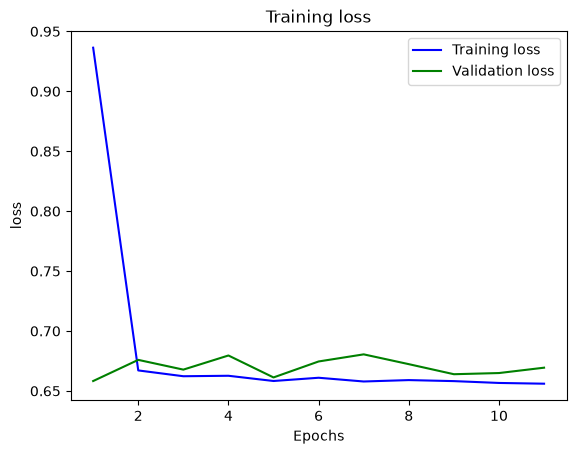

In [44]:
loss = history.history['loss']
val_loss= history.history['val_loss']
epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'g', label='Validation loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [45]:
# No olvidar recargar  modelo los mejores pesos encontrados
model.load_weights('/tmp/checkpoints/models.keras')

In [46]:
predictions= model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [47]:
predictions.shape

(200, 1)

In [48]:
y_test.shape

(200,)

In [49]:
df_y=pd.DataFrame(np.concatenate((predictions, y_test.reshape(-1,1)),axis=1), columns=['predictions','true'])

In [50]:
df_y

,predictions,true
0,0.355465,0.0
1,0.731611,1.0
2,0.345792,0.0
3,0.337610,1.0
4,0.556239,0.0
...,...,...
195,0.617075,1.0
196,0.287514,0.0
197,0.447657,0.0
198,0.384339,0.0


In [51]:
df_y['predict_bin']=(df_y['predictions']>0.5).astype(int)

In [52]:
df_y

,predictions,true,predict_bin
0,0.355465,0.0,0
1,0.731611,1.0,1
2,0.345792,0.0,0
3,0.337610,1.0,0
4,0.556239,0.0,1
...,...,...,...
195,0.617075,1.0,1
196,0.287514,0.0,0
197,0.447657,0.0,0
198,0.384339,0.0,0


In [53]:
df_y['true'].value_counts()

true
1.0    108
0.0     92
Name: count, dtype: int64

In [54]:
confusion_matrix(df_y['true'].astype(int),df_y['predict_bin'])
precision = precision_score(df_y['true'].astype(int), df_y['predict_bin'])
recall = recall_score(df_y['true'].astype(int), df_y['predict_bin'])
f1 = f1_score(df_y['true'].astype(int), df_y['predict_bin'])

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Precision: 0.6625
Recall: 0.4907
F1-Score: 0.5638


## Punto 1 (20%)

Esta red aún no presenta un buen comportamiento en el conjunto de datos. Explore los hiperparámetros de la red para realizar una clasificación adecuada, mida el performance utilizando métricas de clasificación. Justifique los pasos que lo llevaron a escoger el modelo utilizando las curvas del proceso de aprendizaje. Grafique las fronteras de decisión encontradas.

# Que se pretende hacer

Se haran varias iteraciones adicionando 1 y 2 capass intermedias cada una variando entre 4 y 8 neuronas. Al usar el early stopping 

In [72]:
# Grid de arquitecturas: todas las combinaciones posibles con 0, 1 o 2 capas ocultas,
# usando entre 1 y 8 neuronas por capa
import itertools

neuron_options = list(range(1, 9))
max_hidden_layers = 2

architectures = [[]]  # 0 capas ocultas
for n_layers in range(1, max_hidden_layers + 1):
    for combo in itertools.product(neuron_options, repeat=n_layers):
        architectures.append(list(combo))

callback_early = EarlyStopping(monitor='val_loss', mode='min', patience=10)

results = []
histories = {}

for arch in architectures:
    arch_label = str(arch) if arch else '[] (sin capas ocultas)'
    checkpoint_path = f'/tmp/checkpoints/model_{"-".join(map(str, arch)) or "0"}.keras'
    callback_checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', mode='min', save_best_only=True)

    model = keras.Sequential([keras.Input(shape=(len(X_train[1]),))])
    for units in arch:
        model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=[keras.metrics.Accuracy()])

    history = model.fit(
        x=X_train, y=y_train, epochs=300, batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[callback_early, callback_checkpoint],
        verbose=0
    )
    model.load_weights(checkpoint_path)

    predictions = model.predict(X_test, verbose=0)
    predict_bin = (predictions > 0.5).astype(int).reshape(-1)
    y_true = y_test.astype(int)

    precision = precision_score(y_true, predict_bin)
    recall = recall_score(y_true, predict_bin)
    f1 = f1_score(y_true, predict_bin)

    results.append({
        'arquitectura': arch_label,
        'val_loss_min': min(history.history['val_loss']),
        'epocas_entrenadas': len(history.history['loss']),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })
    histories[arch_label] = (history, model, predict_bin, y_true)

results_df = pd.DataFrame(results).sort_values('val_loss_min', ascending=True).reset_index(drop=True)
results_df


I0000 00:00:1789436898.704781  553292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1221927__.7
I0000 00:00:1789436906.533073  553293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1233198__.7
I0000 00:00:1789436915.327188  553293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1247196__.7
I0000 00:00:1789436920.359899  553287 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1255002__.7
I0000 00:00:1789436925.343598  553289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1262144__.7
I0000 00:00:1789436931.221726  553289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1270687__.7
I0000 00:00:1789436934.959100  553293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1275433__.7
/home/micho/Code/MachineLearning/venv_stable/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:

,arquitectura,val_loss_min,epocas_entrenadas,precision,recall,f1
0,"[6, 8]",0.004561,148,1.000000,1.0,1.000000
1,"[6, 5]",0.023750,227,0.972973,1.0,0.986301
2,"[8, 5]",0.024856,128,0.972973,1.0,0.986301
3,"[5, 6]",0.048334,209,0.990826,1.0,0.995392
4,"[7, 4]",0.120324,113,0.892562,1.0,0.943231
...,...,...,...,...,...,...
68,"[2, 4]",0.691211,11,0.000000,0.0,0.000000
69,"[1, 2]",0.692104,11,0.000000,0.0,0.000000
70,"[1, 1]",0.692351,30,0.000000,0.0,0.000000
71,"[1, 8]",0.692464,15,0.000000,0.0,0.000000


### Mejor configuración encontrada

Seleccionamos la arquitectura con menor `val_loss_min` (error de validación), no la de mejor F1 en test: usar el test set para elegir el modelo sesgaría la evaluación final ("test set leakage"). El test set se reserva únicamente para reportar el desempeño del modelo ya elegido.


Mejor arquitectura: [6, 8]


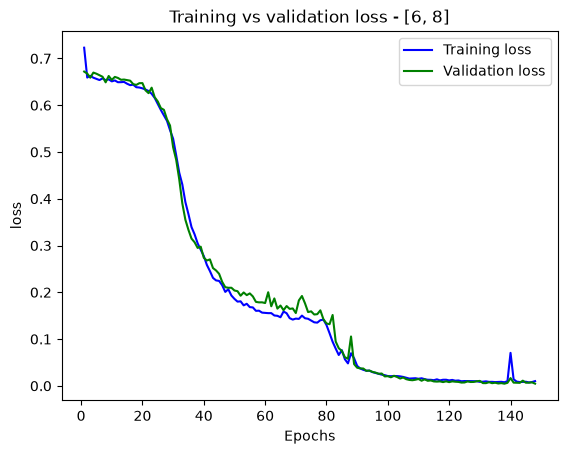

In [76]:
best_label = results_df.iloc[0]['arquitectura']
best_history, best_model, best_predict_bin, best_y_true = histories[best_label]

print(f"Mejor arquitectura: {best_label}")

loss = best_history.history['loss']
val_loss = best_history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'g', label='Validation loss')
plt.title(f'Training vs validation loss - {best_label}')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


### Verificación sobre el set de test

Revisamos individualmente las predicciones del mejor modelo (elegido por validación) frente a las etiquetas reales del test set.


In [80]:
best_predictions = best_model.predict(X_test, verbose=0)
df_y_best = pd.DataFrame(np.concatenate((best_predictions, y_test.reshape(-1, 1)), axis=1), columns=['predictions', 'true'])
df_y_best['predict_bin'] = (df_y_best['predictions'] > 0.5).astype(int)
df_y_best


,predictions,true,predict_bin
0,1.133973e-07,0.0,0
1,9.999369e-01,1.0,1
2,1.111692e-05,0.0,0
3,9.935574e-01,1.0,1
4,1.617196e-02,0.0,0
...,...,...,...
195,9.791924e-01,1.0,1
196,1.141046e-07,0.0,0
197,2.233851e-01,0.0,0
198,1.518882e-08,0.0,0


In [81]:
confusion_matrix(best_y_true, best_predict_bin)


array([[ 92,   0],
       [  0, 108]])

In [82]:
precision = precision_score(best_y_true, best_predict_bin)
recall = recall_score(best_y_true, best_predict_bin)
f1 = f1_score(best_y_true, best_predict_bin)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


### Frontera de decisión del mejor modelo


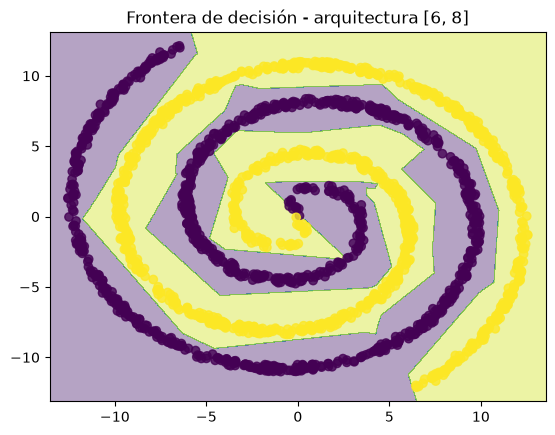

In [83]:
# Frontera de decisión del mejor modelo encontrado en el grid (arquitectura seleccionada por val_loss)

h = .02

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z = (Z > 0.5).astype(int).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
plt.title(f'Frontera de decisión - arquitectura {best_label}')
plt.show()


### Chequeo de robustez: re-generando las espirales con otra semilla

Para descartar que la arquitectura ganadora simplemente tuvo suerte con la partición de validación usada en el grid (73 configuraciones comparadas sobre un validation set de ~200 muestras), regeneramos el dataset de espirales con otra semilla y otro split train/val/test, y reentrenamos **la misma arquitectura ganadora** desde cero. Si el desempeño se mantiene alto, es una señal de que la elección generaliza y no fue solo un golpe de suerte en la partición original.


In [84]:
import ast

def parse_arch_label(label):
    if label.startswith('[]'):
        return []
    return ast.literal_eval(label)

best_arch = parse_arch_label(best_label)

# Regeneramos el dataset con otra semilla y otro split
np.random.seed(123)
X_seed2, y_seed2 = twospirals(N)
X_train2, X_val_test2, y_train2, y_val_test2 = train_test_split(X_seed2, y_seed2, test_size=0.20, random_state=7)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_val_test2, y_val_test2, test_size=0.5, random_state=7)

callback_early2 = EarlyStopping(monitor='val_loss', mode='min', patience=10)
checkpoint_path2 = '/tmp/checkpoints/model_seed_check.keras'
callback_checkpoint2 = ModelCheckpoint(filepath=checkpoint_path2, monitor='val_loss', mode='min', save_best_only=True)

model_check = keras.Sequential([keras.Input(shape=(len(X_train2[1]),))])
for units in best_arch:
    model_check.add(layers.Dense(units, activation='relu'))
model_check.add(layers.Dense(1, activation='sigmoid'))
model_check.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=[keras.metrics.Accuracy()])

history_check = model_check.fit(
    x=X_train2, y=y_train2, epochs=300, batch_size=32,
    validation_data=(X_val2, y_val2),
    callbacks=[callback_early2, callback_checkpoint2],
    verbose=0
)
model_check.load_weights(checkpoint_path2)

print(f"Arquitectura evaluada: {best_arch}")


I0000 00:00:1789439053.225405  553289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2873290__.8


Arquitectura evaluada: [6, 8]


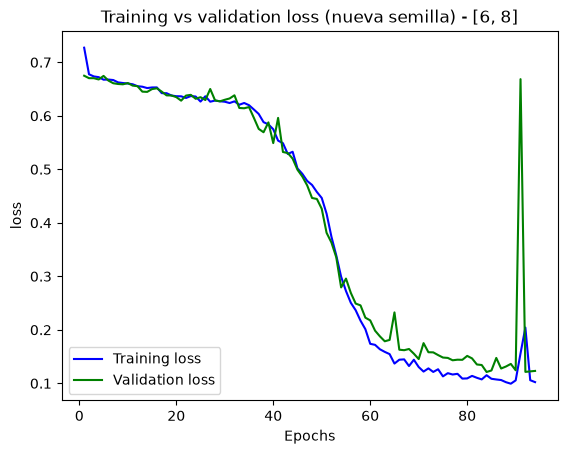

In [92]:
loss = history_check.history['loss']
val_loss = history_check.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'g', label='Validation loss')
plt.title(f'Training vs validation loss (nueva semilla) - {best_arch}')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


In [88]:
predictions_check = model_check.predict(X_test2, verbose=0)
predict_bin_check = (predictions_check > 0.5).astype(int).reshape(-1)
y_true_check = y_test2.astype(int)

print(confusion_matrix(y_true_check, predict_bin_check))
print(f"Precision: {precision_score(y_true_check, predict_bin_check):.4f}")
print(f"Recall: {recall_score(y_true_check, predict_bin_check):.4f}")
print(f"F1-Score: {f1_score(y_true_check, predict_bin_check):.4f}")


[[99  4]
 [ 9 88]]
Precision: 0.9565
Recall: 0.9072
F1-Score: 0.9312


## Punto 2 (80%)

Descargue del archivo disponible en Brightspace. Los datos son de una tarea de clasificación misteriosa. Se le han suministrado 2 datasets: public_dataset y quiz.

Ud debe en el taller construir un modelo de redes neuronales que prediga la variable label.

Además de su informe y código que usualmente se deben entregar en el taller, debe entregar un archivo Python ejecutable que lea los pesos de la red creada, lea el archivo quiz.csv y cree un archivo llamado answers.txt con la etiqueta predicha para cada elemento del archivo quiz.csv en orden. No olvide probar este script ya que se verificará que efectivamente corre para poder asignar el bono.

Los 2 grupos con mejor desempeño en el dataset quiz, tendrán bono en la nota del taller 2.


In [59]:
mistery_df = pd.read_csv('public_dataset.csv')

In [60]:
mistery_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,y
count,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,...,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000
mean,0.342476,0.354463,0.058021,0.494420,1.176614,0.230696,0.972138,0.058583,0.039797,0.127770,...,0.182527,0.666906,0.488058,0.019386,0.081281,0.058094,0.010725,0.418865,0.747534,0.132127
std,0.406351,0.417992,0.128500,0.480492,0.751341,0.327121,0.742960,0.187561,0.094971,0.237038,...,0.256415,0.512845,0.418989,0.066283,0.160882,0.140125,0.044403,0.422058,0.608666,0.338687
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.023066,0.035264,0.000000,0.102553,0.586936,0.007119,0.330180,0.000000,0.000000,0.000000,...,0.013782,0.253250,0.154759,0.000000,0.000000,0.000000,0.000000,0.095496,0.268458,0.000000
50%,0.194912,0.192938,0.000000,0.332578,1.080467,0.092800,0.850545,0.000000,0.000127,0.025366,...,0.084480,0.594218,0.399909,0.000000,0.006765,0.000000,0.000000,0.299459,0.606104,0.000000
75%,0.520104,0.543504,0.053929,0.778229,1.639718,0.320401,1.499929,0.006930,0.036855,0.147220,...,0.247334,0.960084,0.723942,0.000000,0.088406,0.043783,0.000000,0.609748,1.085342,0.000000
max,2.335996,2.921607,1.430971,2.277370,4.134388,2.520059,3.612562,2.451963,1.704229,2.065604,...,2.720396,3.056784,2.456223,0.812189,2.304339,1.607058,0.581389,3.201215,3.583878,1.000000


In [61]:
mistery_df.loc[:,'y'].value_counts()

y
0    2542
1     387
Name: count, dtype: int64

In [62]:
quiz_df=pd.read_csv('quiz.csv')

In [63]:
quiz_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
count,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,...,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000
mean,0.342454,0.371024,0.061540,0.491218,1.230688,0.249682,1.020807,0.070701,0.040666,0.151688,...,0.749684,0.172794,0.691613,0.514076,0.021476,0.093828,0.049963,0.008136,0.445528,0.737791
std,0.416616,0.435255,0.134569,0.486466,0.787169,0.359149,0.754492,0.225102,0.081748,0.279020,...,0.500853,0.246918,0.527916,0.433244,0.074467,0.181009,0.117180,0.039590,0.446731,0.588029
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.020013,0.039751,0.000000,0.101288,0.613530,0.008309,0.366000,0.000000,0.000000,0.000000,...,0.380325,0.013094,0.257972,0.155174,0.000000,0.000000,0.000000,0.000000,0.097457,0.282414
50%,0.182211,0.189905,0.000000,0.324742,1.147500,0.098154,0.917868,0.000000,0.001565,0.028728,...,0.644892,0.079264,0.620742,0.443216,0.000000,0.009880,0.000000,0.000000,0.314257,0.602141
75%,0.502974,0.561788,0.061208,0.800804,1.679488,0.351514,1.574616,0.003505,0.044417,0.179824,...,1.007451,0.229436,1.025037,0.780950,0.000000,0.095591,0.039068,0.000000,0.653772,1.036145
max,2.209104,2.428065,1.076809,2.113466,4.408184,2.191603,3.221736,1.747430,1.025159,2.635898,...,2.973301,1.788658,2.932993,2.370526,0.787230,1.631747,0.986486,0.454402,2.651983,3.408154
